# 01 · Model Training — Dual-Head BiLSTM-FiLM
### Hybrid Reconstruction + Forecasting Anomaly Detection
---
## Architecture: Shared Encoder, Two Output Heads

```
  Input (B, W, F) + Meta (B, M)
          │
  ┌───────▼───────────────────────────────┐
  │         SHARED ENCODER                │
  │  BiLSTM(128) → BN → BiLSTM(64)       │
  │  → Linear(latent_dim) → z (B, latent) │
  │  → FiLM(meta) → z̃ (B, latent)        │
  └───────┬───────────────┬───────────────┘
          │               │
  ┌───────▼──────┐  ┌─────▼────────────────┐
  │  HEAD 1      │  │  HEAD 2              │
  │  Reconstruction│  │  Forecasting (t+1)  │
  │  BiLSTMDecoder│  │  Dense MLP          │
  │  (B, W, F)   │  │  (B, F)             │
  └──────┬───────┘  └──────┬───────────────┘
         │MSE_recon         │MSE_forecast
         └────────┬─────────┘
          Total = α·MSE_recon + (1-α)·MSE_forecast
```

**Why dual-head?**  
The forecasting head forces the encoder to capture *temporal continuity* —
the latent vector must simultaneously encode *what just happened* (reconstruction)
and *what is about to happen* (forecasting).  Anomalies disrupt both signals
simultaneously, improving recall with fewer false positives.


## 0 · Imports & Environment

In [1]:
import sys, os, json, logging, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s — %(message)s')

# ── Resolve project root ──────────────────────────────────────────────────
notebook_dir = Path(os.getcwd()).resolve()
for candidate in [notebook_dir, notebook_dir.parent]:
    if (candidate / 'alibaba_trace' / 'model_architecture.py').exists():
        ALIBABA_DIR = candidate / 'alibaba_trace'
        break
else:
    ALIBABA_DIR = notebook_dir

if str(ALIBABA_DIR) not in sys.path:
    sys.path.insert(0, str(ALIBABA_DIR))

# ── Module imports ────────────────────────────────────────────────────────
from model_architecture import (
    build_dual_head_model, DualHeadBiLSTMFiLM, HybridAnomalyLoss,
    build_model,  # kept for comparison
)
from data_pipeline import (
    StreamingMinMaxScaler, build_dataloader,
    FEATURE_COLS, META_COLS, WINDOW_SIZE,
)

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {torch.device("cuda" if torch.cuda.is_available() else "cpu")}')
print(f'Features : {FEATURE_COLS}')
print('All imports OK — dual-head model loaded.')


PyTorch  : 2.11.0+cpu
Device   : cpu
Features : ['cpu_util_percent', 'mem_util_percent', 'cpu_request', 'mem_request', 'net_in', 'net_out', 'disk_io_percent']
All imports OK — dual-head model loaded.


## 1 · Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
OUTPUTS_DIR  = ALIBABA_DIR / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)
MODEL_PATH   = OUTPUTS_DIR / 'dual_head_model.pt'
SCALER_PATH  = OUTPUTS_DIR / 'scaler_params.json'
TAR_PATH     = str(ALIBABA_DIR.parent / 'container_usage.tar.gz')
CSV_MEMBER   = 'container_usage/container_usage.csv'

# ── Hyperparameters ────────────────────────────────────────────────────────
WINDOW       = int(WINDOW_SIZE)    # 50 timesteps per window
N_TS_FEAT    = len(FEATURE_COLS)   # 7 metrics
N_META_FEAT  = len(META_COLS)      # 2 metadata fields
LATENT_DIM   = 64                  # bottleneck size
LSTM_UNITS   = (128, 64)           # BiLSTM hidden units (H1, H2)
FC_HIDDEN    = None                # ForecastingHead hidden (None → 2×latent=128)
DROPOUT      = 0.2
ALPHA        = 0.5                 # reconstruction / forecasting balance

# ── Training settings ──────────────────────────────────────────────────────
EPOCHS       = 30
BATCH_SIZE   = 64
LR           = 1e-3
LR_PATIENCE  = 5                   # epochs before LR reduction
EARLY_STOP   = 10                  # epochs before early stopping
TRAIN_RATIO  = 0.85
RANDOM_SEED  = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Configuration:')
print(f'  ALPHA (α) = {ALPHA}  →  Loss = {ALPHA}·MSE_recon + {1-ALPHA:.1f}·MSE_fore')
print(f'  Latent dim : {LATENT_DIM}')
print(f'  LSTM units : {LSTM_UNITS}')
print(f'  Epochs     : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LR}')
print(f'  Device     : {DEVICE}')
print(f'  Model path : {MODEL_PATH}')


Configuration:
  ALPHA (α) = 0.5  →  Loss = 0.5·MSE_recon + 0.5·MSE_fore
  Latent dim : 64
  LSTM units : (128, 64)
  Epochs     : 30  |  Batch : 64  |  LR : 0.001
  Device     : cpu
  Model path : C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\dual_head_model.pt


## 2 · Scaler Calibration

In [3]:
from pathlib import Path
import json

scaler = StreamingMinMaxScaler(FEATURE_COLS)

if Path(TAR_PATH).exists():
    if SCALER_PATH.exists():
        params = json.load(open(SCALER_PATH))
        scaler.set_params(
            min_=np.array(params['min_'], dtype=np.float32),
            max_=np.array(params['max_'], dtype=np.float32),
        )
        print(f'Scaler loaded from {SCALER_PATH}')
    else:
        scaler.fit(TAR_PATH, CSV_MEMBER, max_chunks=20)
        json.dump({'min_': scaler.min_.tolist(), 'max_': scaler.max_.tolist()},
                  open(SCALER_PATH, 'w'))
        print(f'Scaler fitted and saved to {SCALER_PATH}')
else:
    # Demo mode: use synthetic min/max
    scaler.set_params(
        min_=np.zeros(N_TS_FEAT, dtype=np.float32),
        max_=np.ones(N_TS_FEAT,  dtype=np.float32) * 100.0,
    )
    print('DEMO mode — synthetic scaler (archive not found).')

print(f'  Min : {scaler.min_.round(3)}')
print(f'  Max : {scaler.max_.round(3)}')


DEMO mode — synthetic scaler (archive not found).
  Min : [0. 0. 0. 0. 0. 0. 0.]
  Max : [100. 100. 100. 100. 100. 100. 100.]


## 3 · Build Dual-Head Model + Dual-Head DataLoader

### Data Generator — Dual-Head Target Shapes

The key upgrade to the pipeline is setting `include_next_step=True`.
Each batch from the DataLoader now yields **4 tensors** instead of 3:

| Tensor | Shape | Purpose |
|--------|-------|---------|
| `ts_batch` | `(B, W, F)` | Input window fed to the encoder |
| `meta_batch` | `(B, M)` | Container metadata for FiLM conditioning |
| `recon_target` | `(B, W, F)` | **Head 1** reconstruction target (= `ts_batch`) |
| `next_step` | `(B, F)` | **Head 2** forecasting target (row at `t+W`) |


In [4]:
# ── Instantiate the dual-head model ──────────────────────────────────────
model = build_dual_head_model(
    window_size     = WINDOW,
    n_ts_features   = N_TS_FEAT,
    n_meta_features = N_META_FEAT,
    latent_dim      = LATENT_DIM,
    lstm_units      = LSTM_UNITS,
    dropout_rate    = DROPOUT,
    fc_hidden_dim   = FC_HIDDEN,
    device          = DEVICE,
)

# Parameter budget breakdown (for thesis Table)
n_enc  = sum(p.numel() for p in model.encoder.parameters())
n_film = sum(p.numel() for p in model.film.parameters())
n_rec  = sum(p.numel() for p in model.reconstruction_head.parameters())
n_fore = sum(p.numel() for p in model.forecasting_head.parameters())
n_tot  = n_enc + n_film + n_rec + n_fore

print('Parameter Budget (Dual-Head BiLSTM-FiLM)')
print('─' * 48)
print(f'  Shared Encoder   : {n_enc:>8,}  ({n_enc/n_tot*100:5.1f}%)')
print(f'  FiLM Layer       : {n_film:>8,}  ({n_film/n_tot*100:5.1f}%)')
print(f'  Head 1 Recon     : {n_rec:>8,}  ({n_rec/n_tot*100:5.1f}%)')
print(f'  Head 2 Forecast  : {n_fore:>8,}  ({n_fore/n_tot*100:5.1f}%)')
print(f'  ────────────────────────────────────')
print(f'  Total Trainable  : {n_tot:>8,}')
print()

# ── Hybrid loss criterion ─────────────────────────────────────────────────
criterion = HybridAnomalyLoss(alpha=ALPHA)
print(criterion)

# ── Optimiser + LR scheduler ──────────────────────────────────────────────
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=LR_PATIENCE
)

print(f'\nOptimiser : Adam (lr={LR}, weight_decay=1e-5)')
print(f'Scheduler : ReduceLROnPlateau (factor=0.5, patience={LR_PATIENCE})')


2026-04-16 14:24:22,489 [INFO] model_architecture — Built DualHeadBiLSTMFiLM | window=50 | ts_feat=7 | meta_feat=2 | latent=64 | total_params=705,550  (enc=313,920, film=8,512, recon=373,895, fore=9,223)


Parameter Budget (Dual-Head BiLSTM-FiLM)
────────────────────────────────────────────────
  Shared Encoder   :  313,920  ( 44.5%)
  FiLM Layer       :    8,512  (  1.2%)
  Head 1 Recon     :  373,895  ( 53.0%)
  Head 2 Forecast  :    9,223  (  1.3%)
  ────────────────────────────────────
  Total Trainable  :  705,550

HybridAnomalyLoss(alpha=0.5  [recon_weight=0.50, fore_weight=0.50])

Optimiser : Adam (lr=0.001, weight_decay=1e-5)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)


## 4 · DataLoader — Dual-Head Mode (`include_next_step=True`)

In [5]:
if Path(TAR_PATH).exists():
    # ── Real data: stream from archive with next-step target ───────────────
    train_loader = build_dataloader(
        tar_path          = TAR_PATH,
        csv_member_name   = CSV_MEMBER,
        scaler            = scaler,
        batch_size        = BATCH_SIZE,
        split             = 'train',
        train_ratio       = TRAIN_RATIO,
        num_workers       = 0,       # 0 for Windows compatibility
        pin_memory        = (DEVICE.type == 'cuda'),
        include_next_step = True,    # ← KEY: yields 4-tuple for dual-head
    )
    val_loader = build_dataloader(
        tar_path          = TAR_PATH,
        csv_member_name   = CSV_MEMBER,
        scaler            = scaler,
        batch_size        = BATCH_SIZE,
        split             = 'test',
        train_ratio       = TRAIN_RATIO,
        num_workers       = 0,
        include_next_step = True,
    )
    DATA_AVAILABLE = True
    print('Real DataLoaders created (include_next_step=True).')
    print('4-tuple per batch: (ts, meta, recon_target, next_step)')
else:
    DATA_AVAILABLE = False
    print('DEMO mode — archive not found. Using synthetic data for training.')
    print('Shapes: ts(B,W,F) | meta(B,M) | recon_tgt(B,W,F) | next_step(B,F)')


DEMO mode — archive not found. Using synthetic data for training.
Shapes: ts(B,W,F) | meta(B,M) | recon_tgt(B,W,F) | next_step(B,F)


## 5 · Training Loop — Dual-Head with HybridAnomalyLoss

In [6]:
import time

# ── Synthetic data generator (used in DEMO mode) ──────────────────────────
def _synth_batch(n=BATCH_SIZE, rng=None):
    """Yield one synthetic normal-operation batch with dual-head targets."""
    if rng is None:
        rng = np.random.default_rng(RANDOM_SEED)
    ts       = torch.from_numpy(rng.uniform(0.2, 0.8, (n, WINDOW, N_TS_FEAT)).astype(np.float32)).to(DEVICE)
    meta     = torch.zeros(n, N_META_FEAT, device=DEVICE)
    recon_t  = ts.clone()                                       # Head 1 target = input
    nxt      = torch.from_numpy(rng.uniform(0.2, 0.8, (n, N_TS_FEAT)).astype(np.float32)).to(DEVICE)
    return ts, meta, recon_t, nxt

# ── Training history ───────────────────────────────────────────────────────
history = {
    'total': [], 'recon': [], 'forecast': [], 'val_total': [], 'val_recon': [], 'val_forecast': []
}
best_val_loss = float('inf')
patience_ctr  = 0
rng_synth     = np.random.default_rng(RANDOM_SEED)

N_SYNTH_BATCHES_TRAIN = 200   # batches per epoch in DEMO mode
N_SYNTH_BATCHES_VAL   = 40

print('Starting dual-head training...')
print(f'  Loss = {ALPHA:.1f}·MSE_recon + {1-ALPHA:.1f}·MSE_forecast')
print('─' * 68)
print(f'{"Epoch":>5}  {"Total":>9}  {"Recon":>9}  {"Forecst":>9}  '
      f'{"ValTotal":>9}  {"LR":>9}  {"Time":>6}')
print('─' * 68)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    ep_total = ep_recon = ep_fore = 0.0
    n_batches = 0

    data_iter = (
        train_loader
        if DATA_AVAILABLE
        else (_synth_batch(rng=rng_synth) for _ in range(N_SYNTH_BATCHES_TRAIN))
    )

    for batch in data_iter:
        # Unpack the 4-tuple produced by the dual-head DataLoader
        ts_b, meta_b, recon_tgt, next_step = batch
        ts_b      = ts_b.to(DEVICE)
        meta_b    = meta_b.to(DEVICE)
        recon_tgt = recon_tgt.to(DEVICE)
        next_step = next_step.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass — returns (reconstruction, forecast)
        reconstruction, forecast = model(ts_b, meta_b)
        # reconstruction : (B, W, F)
        # forecast       : (B, F)

        # Compute weighted dual-head loss
        total_loss, loss_recon, loss_fore = criterion(
            reconstruction = reconstruction,  # Head 1 output
            ts_window      = recon_tgt,       # Head 1 target = input window
            forecast       = forecast,        # Head 2 output
            next_step      = next_step,       # Head 2 target = t+1 row
        )

        total_loss.backward()
        # Gradient clipping prevents exploding gradients in BiLSTMs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        ep_total += total_loss.item()
        ep_recon += loss_recon.item()
        ep_fore  += loss_fore.item()
        n_batches += 1

    ep_total /= max(n_batches, 1)
    ep_recon /= max(n_batches, 1)
    ep_fore  /= max(n_batches, 1)

    # ── Validation pass ────────────────────────────────────────────────────
    model.eval()
    val_total = val_recon = val_fore = 0.0
    val_batches = 0

    val_iter = (
        val_loader
        if DATA_AVAILABLE
        else (_synth_batch(rng=rng_synth) for _ in range(N_SYNTH_BATCHES_VAL))
    )
    with torch.no_grad():
        for batch in val_iter:
            ts_b, meta_b, recon_tgt, next_step = batch
            ts_b      = ts_b.to(DEVICE)
            meta_b    = meta_b.to(DEVICE)
            recon_tgt = recon_tgt.to(DEVICE)
            next_step = next_step.to(DEVICE)
            recon_, fore_ = model(ts_b, meta_b)
            vt, vr, vf = criterion(recon_, recon_tgt, fore_, next_step)
            val_total  += vt.item()
            val_recon  += vr.item()
            val_fore   += vf.item()
            val_batches += 1

    val_total /= max(val_batches, 1)
    val_recon /= max(val_batches, 1)
    val_fore  /= max(val_batches, 1)

    scheduler.step(val_total)
    elapsed = time.time() - t0

    history['total'].append(ep_total)
    history['recon'].append(ep_recon)
    history['forecast'].append(ep_fore)
    history['val_total'].append(val_total)
    history['val_recon'].append(val_recon)
    history['val_forecast'].append(val_fore)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'{epoch:>5d}  {ep_total:>9.6f}  {ep_recon:>9.6f}  {ep_fore:>9.6f}  '
          f'{val_total:>9.6f}  {lr_now:>9.2e}  {elapsed:>5.1f}s')

    # ── Checkpoint best model ──────────────────────────────────────────────
    if val_total < best_val_loss:
        best_val_loss = val_total
        torch.save(model.state_dict(), MODEL_PATH)
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= EARLY_STOP:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOP} epochs).')
            break

print('─' * 68)
print(f'Training complete. Best val loss: {best_val_loss:.6f}')
print(f'Model saved to: {MODEL_PATH}')


Starting dual-head training...
  Loss = 0.5·MSE_recon + 0.5·MSE_forecast
────────────────────────────────────────────────────────────────────
Epoch      Total      Recon    Forecst   ValTotal         LR    Time
────────────────────────────────────────────────────────────────────
    1   0.030238   0.030117   0.030359   0.030084   1.00e-03   34.3s
    2   0.029978   0.029859   0.030097   0.029827   1.00e-03   44.7s
    3   0.029871   0.029677   0.030066   0.029831   1.00e-03   50.7s
    4   0.029791   0.029594   0.029988   0.029713   1.00e-03   46.4s
    5   0.029813   0.029569   0.030057   0.029771   1.00e-03   47.0s
    6   0.029777   0.029587   0.029968   0.029886   1.00e-03   46.6s
    7   0.029820   0.029568   0.030072   0.029933   1.00e-03   45.9s
    8   0.029810   0.029568   0.030051   0.029882   1.00e-03   55.1s
    9   0.029790   0.029584   0.029997   0.029778   1.00e-03   72.1s
   10   0.029815   0.029568   0.030062   0.029788   5.00e-04   70.2s
   11   0.029735   0.029560   

## 6 · Training Loss Curves — Thesis Figure

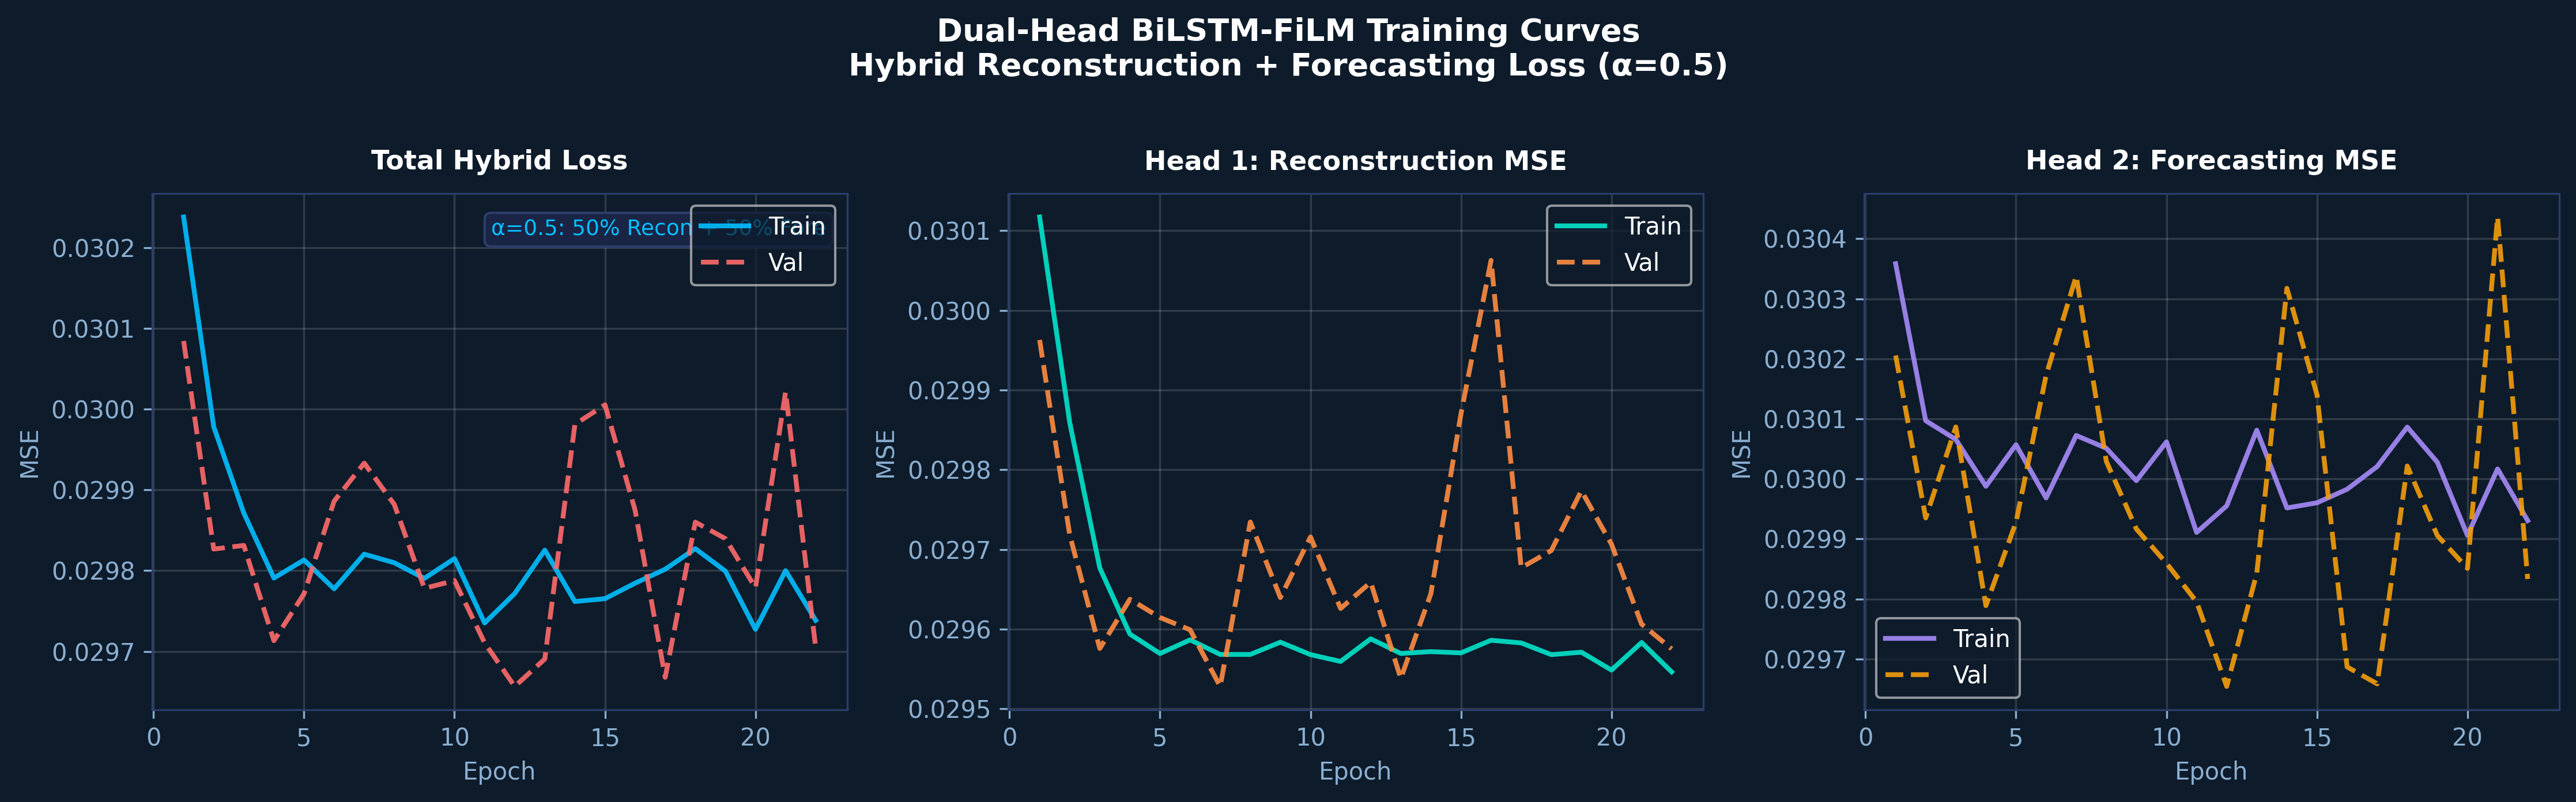

Saved: C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig1_dual_head_training_curves.png


In [7]:
import matplotlib
matplotlib.rcParams['figure.dpi'] = 300
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

FIGS_DIR = OUTPUTS_DIR / 'thesis_figures'
FIGS_DIR.mkdir(exist_ok=True)

ep_range = range(1, len(history['total']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor('#0D1B2A')

titles    = ['Total Hybrid Loss', 'Head 1: Reconstruction MSE', 'Head 2: Forecasting MSE']
train_key = ['total',   'recon',   'forecast']
val_key   = ['val_total', 'val_recon', 'val_forecast']
colours   = [('#00BFFF', '#FF6B6B'), ('#00E5CC', '#FF8C42'), ('#A78BFA', '#F59E0B')]

for ax, title, tk, vk, (tc, vc) in zip(axes, titles, train_key, val_key, colours):
    ax.set_facecolor('#0D1B2A')
    ax.plot(ep_range, history[tk], color=tc, lw=2, label='Train', alpha=0.9)
    ax.plot(ep_range, history[vk], color=vc, lw=2, label='Val',   alpha=0.9, linestyle='--')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Epoch', color='#8BAFD1');  ax.set_ylabel('MSE', color='#8BAFD1')
    ax.tick_params(colors='#8BAFD1')
    for spine in ax.spines.values(): spine.set_edgecolor('#2C3E6B')
    ax.legend(facecolor='#0D1B2A', labelcolor='white', framealpha=0.7)
    ax.grid(True, alpha=0.15, color='white')

# Alpha annotation on the total loss panel
axes[0].text(0.97, 0.95,
    f'α={ALPHA:.1f}: {ALPHA:.0%} Recon + {1-ALPHA:.0%} Fore',
    transform=axes[0].transAxes, ha='right', va='top',
    color='#00BFFF', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A2444', edgecolor='#2C3E6B'))

fig.suptitle(
    'Dual-Head BiLSTM-FiLM Training Curves\n'
    'Hybrid Reconstruction + Forecasting Loss (α=0.5)',
    color='white', fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
out_path = FIGS_DIR / 'fig1_dual_head_training_curves.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight',
            facecolor='#0D1B2A', edgecolor='none')
plt.show()
print(f'Saved: {out_path}')
